In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, mean_squared_error


In [2]:
df = pd.read_csv('cleaned_reviews_sampled_preprocessed.csv')
df.head()

,id,text,rating,title,likes,consumersReviewCountOnSameDomain,consumersReviewCountOnSameLocation,company_name,labels.verification.isVerified,labels.verification.createdDateTime,...,consumer.countryCode,consumer.isVerified,reply.message,reply.publishedDate,reply.updatedDate,location.id,location.name,location.urlFormattedName,continent,clean_text
0,682695d01aadcf94ec3aea94,The tariff. I'm cancelling as soon as I burn t...,1,Tariff = Nope.,0,1,0,fabletics,True,2025-05-16 03:33:04+00:00,...,US,False,"Hello Gwendolyn,\n\nThank you for sharing your...",2025-05-17 04:00:20+00:00,NaN,NaN,NaN,NaN,North America,tariff cancelling soon burn last credit
1,662a212bddb79d3a3b1ead31,I've given a 3 because I'm waiting to make my ...,3,I've given a 3 because I'm waiting to…,0,1,0,freecash,True,2024-04-25 11:23:56+00:00,...,GB,False,NaN,NaN,NaN,NaN,NaN,NaN,Europe,given three waiting make first shout unfortuna...
2,67facfac6e18b4a46adc5750,Nice application for me,5,Nice,0,1,0,freecash,True,2025-04-12 22:40:12+00:00,...,CA,False,NaN,NaN,NaN,NaN,NaN,NaN,North America,nice application
3,5afb76de6d33bc0b083fa127,Easy ordering and customer service is the BEST,5,Easy ordering and customer service is…,0,1,0,cafepress,True,2018-05-16 00:10:06+00:00,...,US,False,NaN,NaN,NaN,NaN,NaN,NaN,North America,easy ordering customer service best
4,59f20aa0dc938904f8e20519,Very Good !!!,5,Very Good !!!,0,1,0,aliexpress.json,True,2017-10-26 16:17:36+00:00,...,RU,False,NaN,NaN,NaN,NaN,NaN,NaN,Asia,good


In [3]:
df_short = df[['id','rating','company_name', 'text', 'clean_text']]
df_short.head()

,id,rating,company_name,text,clean_text
0,682695d01aadcf94ec3aea94,1,fabletics,The tariff. I'm cancelling as soon as I burn t...,tariff cancelling soon burn last credit
1,662a212bddb79d3a3b1ead31,3,freecash,I've given a 3 because I'm waiting to make my ...,given three waiting make first shout unfortuna...
2,67facfac6e18b4a46adc5750,5,freecash,Nice application for me,nice application
3,5afb76de6d33bc0b083fa127,5,cafepress,Easy ordering and customer service is the BEST,easy ordering customer service best
4,59f20aa0dc938904f8e20519,5,aliexpress.json,Very Good !!!,good


In [4]:
categorie_rating = { 1: 'poor', 2: '0', 3: '0', 4: '0', 5: 'good'}

df_short['ratings_categorie'] = df_short['rating'].map(categorie_rating)
df_short.head()

C:\Users\poetzlal\AppData\Local\Temp\ipykernel_20236\4011786614.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_short['ratings_categorie'] = df_short['rating'].map(categorie_rating)


,id,rating,company_name,text,clean_text,ratings_categorie
0,682695d01aadcf94ec3aea94,1,fabletics,The tariff. I'm cancelling as soon as I burn t...,tariff cancelling soon burn last credit,poor
1,662a212bddb79d3a3b1ead31,3,freecash,I've given a 3 because I'm waiting to make my ...,given three waiting make first shout unfortuna...,0
2,67facfac6e18b4a46adc5750,5,freecash,Nice application for me,nice application,good
3,5afb76de6d33bc0b083fa127,5,cafepress,Easy ordering and customer service is the BEST,easy ordering customer service best,good
4,59f20aa0dc938904f8e20519,5,aliexpress.json,Very Good !!!,good,good


In [8]:
df_short.info()
df_short = df_short.dropna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 25000 non-null  object
 1   rating             25000 non-null  int64 
 2   company_name       25000 non-null  object
 3   text               25000 non-null  object
 4   clean_text         24989 non-null  object
 5   ratings_categorie  25000 non-null  object
dtypes: int64(1), object(5)
memory usage: 1.1+ MB


In [9]:
df_short.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24989 entries, 0 to 24999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 24989 non-null  object
 1   rating             24989 non-null  int64 
 2   company_name       24989 non-null  object
 3   text               24989 non-null  object
 4   clean_text         24989 non-null  object
 5   ratings_categorie  24989 non-null  object
dtypes: int64(1), object(5)
memory usage: 1.3+ MB


In [11]:
## vectorizes the column clean_text into features

from sklearn.feature_extraction.text import TfidfVectorizer

texte = df_short["clean_text"].tolist()

vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X_text = vectorizer.fit_transform(texte)

feature_names = vectorizer.get_feature_names_out()
display(feature_names)

array(['able', 'absolute', 'absolutely', 'accept', 'access',
       'accommodation', 'account', 'accurate', 'actual', 'actually',
       'add', 'added', 'additional', 'address', 'advance', 'advertised',
       'affordable', 'agent', 'ago', 'ahead', 'air', 'airline', 'airport',
       'alabama', 'alliance', 'allow', 'allowed', 'alternative',
       'amazing', 'amazon', 'angry', 'answer', 'answered', 'anymore',
       'apartment', 'app', 'apparently', 'apple', 'application', 'apply',
       'appreciate', 'apps', 'april', 'area', 'arrangement', 'arrival',
       'arrive', 'arrived', 'arrives', 'ask', 'asked', 'asking',
       'assistance', 'att', 'attempt', 'attendant', 'available', 'avoid',
       'away', 'awesome', 'awful', 'bad', 'bag', 'bank', 'based',
       'basically', 'beat', 'beautiful', 'bed', 'believe', 'best',
       'better', 'big', 'birthday', 'bit', 'black', 'blanket', 'blue',
       'body', 'book', 'booked', 'booking', 'bottle', 'bought', 'box',
       'bra', 'brand', 'bri

In [13]:
## instantiate Model - first try Logistic regression

# define X and y
X = X_text
y = df_short['ratings_categorie']

# train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1234)

# model training
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [14]:
# prediction
from sklearn.metrics import classification_report

y_pred = model1.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.61      0.40      0.48      1062
        good       0.83      0.93      0.88      3001
        poor       0.73      0.72      0.73       935

    accuracy                           0.78      4998
   macro avg       0.72      0.69      0.70      4998
weighted avg       0.76      0.78      0.77      4998



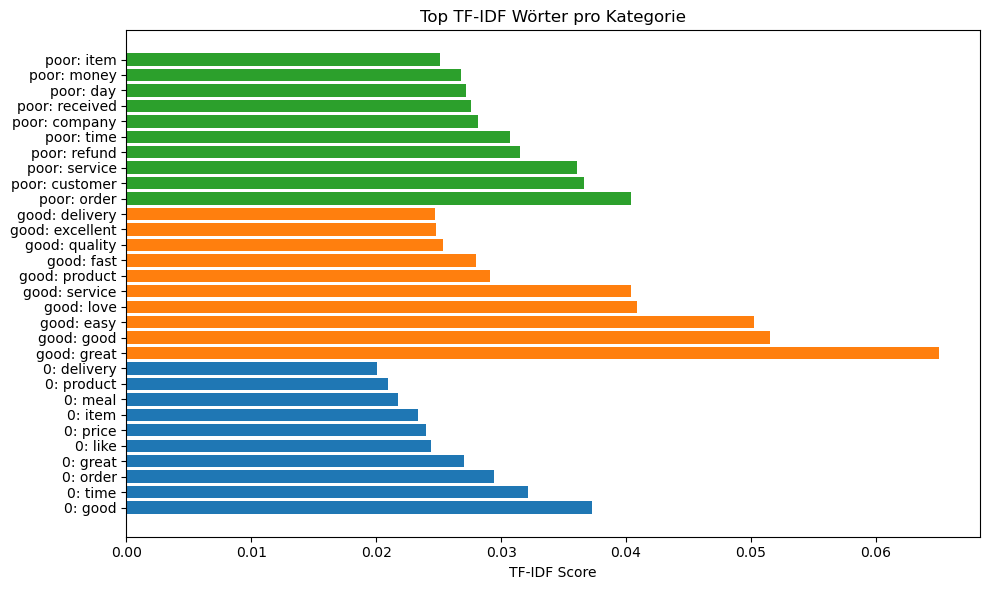

In [19]:
category_top_words = {}
for category in y_train.unique():
    # Indizes der Kategorie
    indices = np.where(y_train == category)[0]
    # Mittelwert der TF-IDF-Werte für diese Kategorie
    mean_tfidf = X_train[indices].mean(axis=0).A1
    # Top-10 Wörter
    top_indices = mean_tfidf.argsort()[::-1][:10]
    top_words = [(feature_names[i], mean_tfidf[i]) for i in top_indices]
    category_top_words[category] = top_words

# Visualisierung
fig, ax = plt.subplots(figsize=(10, 6))
for i, (category, words) in enumerate(category_top_words.items()):
    labels, scores = zip(*words)
    ax.barh([f"{category}: {label}" for label in labels], scores)

ax.set_xlabel("TF-IDF Score")
ax.set_title("Top TF-IDF Wörter pro Kategorie")
plt.tight_layout()
plt.show()


In [20]:
hist_model1_train = X_train
hist_model1_test = X_test

In [23]:
# optimierung LR-Model

model1_opt = LogisticRegression(max_iter=1000, class_weight='balanced')
model1_opt.fit(X_train, y_train)

y_pred_new = model1_opt.predict(X_test)
print(classification_report(y_test, y_pred_new))


              precision    recall  f1-score   support

           0       0.47      0.55      0.50      1062
        good       0.89      0.78      0.83      3001
        poor       0.66      0.79      0.72       935

    accuracy                           0.73      4998
   macro avg       0.67      0.71      0.69      4998
weighted avg       0.76      0.73      0.74      4998



In [27]:
# optimierung mit Vergrößerung von kleinen Klassen:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=420)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

model1_opt2 = LogisticRegression(max_iter=1000)
model1_opt2.fit(X_resampled, y_resampled)

y_pred_new2 = model1_opt2.predict(X_test)
print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.47      0.55      0.50      1062
        good       0.89      0.78      0.83      3001
        poor       0.66      0.79      0.72       935

    accuracy                           0.73      4998
   macro avg       0.67      0.71      0.69      4998
weighted avg       0.76      0.73      0.74      4998



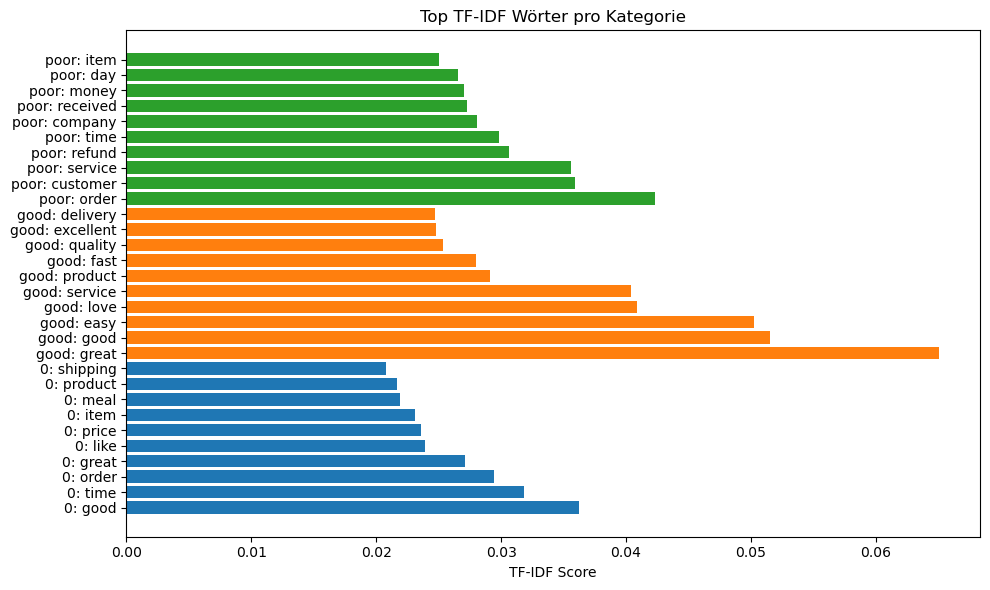

In [28]:
category_top_words2 = {}
for category in y_resampled.unique():
    # Indizes der Kategorie
    indices = np.where(y_resampled == category)[0]
    # Mittelwert der TF-IDF-Werte für diese Kategorie
    mean_tfidf = X_resampled[indices].mean(axis=0).A1
    # Top-10 Wörter
    top_indices = mean_tfidf.argsort()[::-1][:10]
    top_words = [(feature_names[i], mean_tfidf[i]) for i in top_indices]
    category_top_words2[category] = top_words

# Visualisierung
fig, ax = plt.subplots(figsize=(10, 6))
for i, (category, words) in enumerate(category_top_words2.items()):
    labels, scores = zip(*words)
    ax.barh([f"{category}: {label}" for label in labels], scores)

ax.set_xlabel("TF-IDF Score")
ax.set_title("Top TF-IDF Wörter pro Kategorie")
plt.tight_layout()
plt.show();